# Learnability analysis — can the cam-projected heatmap be learned?

Four checks, run on the scaled label prototype (`label_prototypes_lrn.npz`, ~90 groups across all 3 LIBERO splits) before committing to full Round-3 training. Each section corresponds to one check in `scripts/libero/analyze_label_learnability.py`.

Re-run that script first if `label_prototypes_lrn.npz` doesn't exist yet.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path(os.getcwd()).parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from scripts.libero.analyze_label_learnability import (
    load_group_features, check1_nn_predictability,
    check2_variance_decomposition, check3_constant_baseline,
    check4_tiny_mlp,
)

LABELS = REPO_ROOT / "datasets/libero/v1/label_prototypes_lrn.npz"
features, group_keys, labels, manifest = load_group_features(LABELS)
G = features.shape[0]
print(f"G={G} groups, feature dim={features.shape[1]}, label shape={labels.shape[1:]}")

G=90 groups, feature dim=72, label shape=(480, 640)


## Check 1 — Nearest-neighbour predictability

Are similar pre-states associated with similar labels? Compare NN-pair label-cosine to random-pair label-cosine.

**Pass criterion**: NN similarity ≥ 2× random similarity.

NN similarity:     0.2717
Random similarity: 0.0740
Ratio:             3.67x  →  PASS


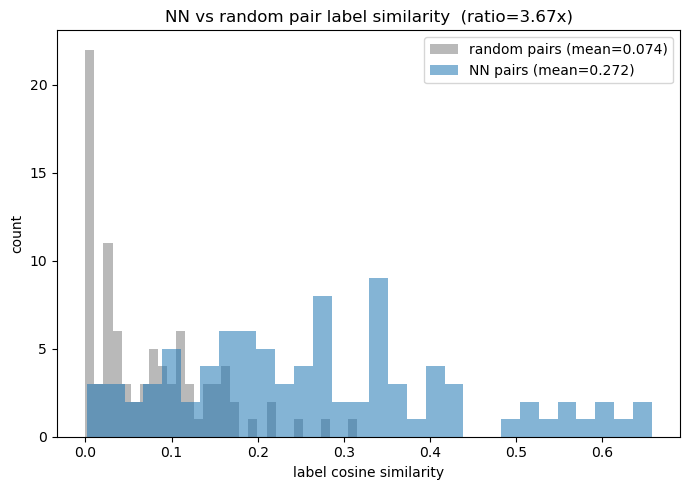

In [2]:
r1 = check1_nn_predictability(features, labels, k=5)
print(f"NN similarity:     {r1['nn_sim']:.4f}")
print(f"Random similarity: {r1['rand_sim']:.4f}")
print(f"Ratio:             {r1['ratio']:.2f}x  →  {'PASS' if r1['passed'] else 'FAIL'}")

# Show per-group NN vs random similarity scatter.
feat_n = features - features.mean(axis=0, keepdims=True)
feat_n /= np.maximum(np.linalg.norm(feat_n, axis=1, keepdims=True), 1e-9)
L = labels.reshape(G, -1)
L_n = L / np.maximum(np.linalg.norm(L, axis=1, keepdims=True), 1e-9)
label_sim = L_n @ L_n.T
feat_sim = feat_n @ feat_n.T

rng = np.random.default_rng(0)
nn_sims, rand_sims = [], []
for g in range(G):
    order = np.argsort(-feat_sim[g])
    nn = [j for j in order if j != g][:5]
    rand = rng.choice([j for j in range(G) if j != g], size=5, replace=False)
    nn_sims.append(label_sim[g, nn].mean())
    rand_sims.append(label_sim[g, rand].mean())

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(rand_sims, bins=30, alpha=0.55, label=f"random pairs (mean={np.mean(rand_sims):.3f})", color="grey")
ax.hist(nn_sims, bins=30, alpha=0.55, label=f"NN pairs (mean={np.mean(nn_sims):.3f})", color="C0")
ax.set_xlabel("label cosine similarity")
ax.set_ylabel("count")
ax.set_title(f"NN vs random pair label similarity  (ratio={r1['ratio']:.2f}x)")
ax.legend()
plt.tight_layout()

## Check 2 — Within-group vs between-group variance

How much of the per-pixel variance is irreducible per-failure noise (within group) vs learnable structure (between groups)?

Computed on `log1p(mass)` (closer to what we'd actually train on) — the raw-mass ratio is reported as a diagnostic. **Pass criterion**: median(within/between) on log1p < 0.5.

log1p within/between ratio:
  median: 0.505  (pass if < 0.5)
  IQR:    [0.346, 0.759]
  raw-mass median (diagnostic): 0.631
  meaningful pixels: 28788
  → FAIL


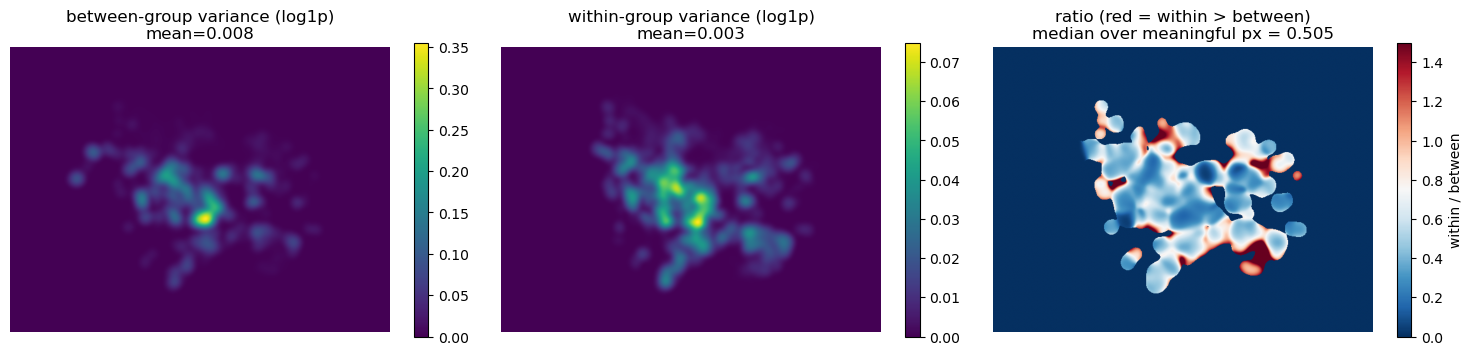

In [3]:
r2 = check2_variance_decomposition(LABELS)
print(f"log1p within/between ratio:")
print(f"  median: {r2['median_ratio']:.3f}  (pass if < 0.5)")
print(f"  IQR:    [{r2['p25']:.3f}, {r2['p75']:.3f}]")
print(f"  raw-mass median (diagnostic): {r2['raw_median']:.3f}")
print(f"  meaningful pixels: {r2['n_meaningful_pixels']}")
print(f"  → {'PASS' if r2['passed'] else 'FAIL'}")

# Visualize per-pixel ratio.
labels_data = np.load(LABELS)
cam_log = np.log1p(labels_data['cam_heatmap_agentview'][..., 0])
group_ids = labels_data['group_ids']
group_log = np.log1p(labels_data['group_cam_heatmap_agentview'])

n_groups = int(group_ids.max()) + 1
within_acc = np.zeros(cam_log.shape[1:], dtype=np.float64)
n_ok = 0
for g in range(n_groups):
    sel = np.where(group_ids == g)[0]
    if sel.size < 2:
        continue
    within_acc += cam_log[sel].var(axis=0, ddof=0)
    n_ok += 1
within_var = within_acc / max(n_ok, 1)
between_var = group_log.var(axis=0, ddof=0)
mask = between_var > 0.01 * between_var.max()
ratio_img = np.where(mask, within_var / np.maximum(between_var, 1e-9), 0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im = axes[0].imshow(between_var, cmap="viridis")
plt.colorbar(im, ax=axes[0], shrink=0.7)
axes[0].set_title(f"between-group variance (log1p)\nmean={between_var.mean():.3f}")
im = axes[1].imshow(within_var, cmap="viridis")
plt.colorbar(im, ax=axes[1], shrink=0.7)
axes[1].set_title(f"within-group variance (log1p)\nmean={within_var.mean():.3f}")
im = axes[2].imshow(ratio_img, cmap="RdBu_r", vmin=0, vmax=1.5)
plt.colorbar(im, ax=axes[2], shrink=0.7, label="within / between")
axes[2].set_title(f"ratio (red = within > between)\nmedian over meaningful px = {r2['median_ratio']:.3f}")
for a in axes:
    a.axis("off")
plt.tight_layout()

## Check 3 — Constant-baseline MSE

The floor any model must beat: predict `mean(log1p(target))` across train groups, evaluate on val.

val MSE  (constant predictor) = 0.0038
train variance                 = 0.0034
normalised (mse/var)           = 1.117
train/val groups: 72 / 18


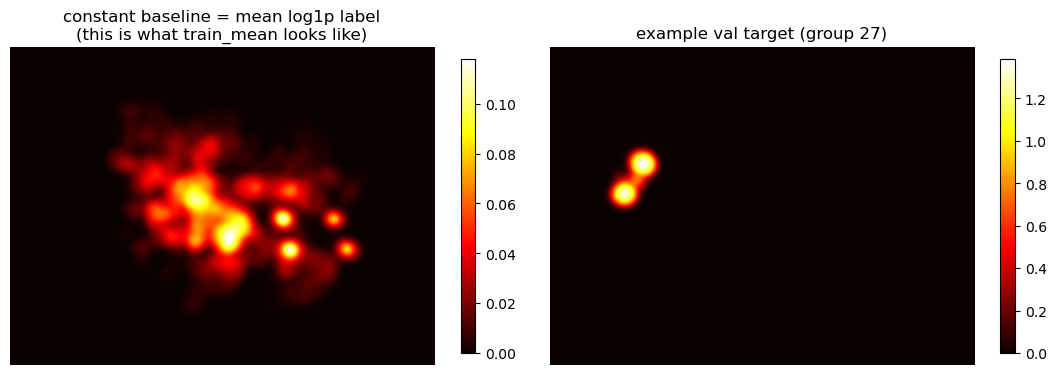

In [4]:
log_labels = np.log1p(labels)
r3 = check3_constant_baseline(log_labels, val_frac=0.2, seed=0)
print(f"val MSE  (constant predictor) = {r3['val_mse']:.4f}")
print(f"train variance                 = {r3['train_var']:.4f}")
print(f"normalised (mse/var)           = {r3['normalized']:.3f}")
print(f"train/val groups: {r3['train_idx'].size} / {r3['val_idx'].size}")

# Visualize the baseline label.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im = axes[0].imshow(r3['baseline'], cmap='hot')
plt.colorbar(im, ax=axes[0], shrink=0.7)
axes[0].set_title(f"constant baseline = mean log1p label\n(this is what train_mean looks like)")
axes[0].axis('off')
im = axes[1].imshow(log_labels[r3['val_idx'][0]], cmap='hot')
plt.colorbar(im, ax=axes[1], shrink=0.7)
axes[1].set_title(f"example val target (group {r3['val_idx'][0]})")
axes[1].axis('off')
plt.tight_layout()

## Check 4 — Tiny MLP on state-only features

Can a state-only MLP (no images) beat the constant baseline? **Pass criterion**: val MSE reduction ≥ 20%.

best val MSE:        0.0036
const baseline MSE:  0.0034
reduction:           -5.6%
→ FAIL


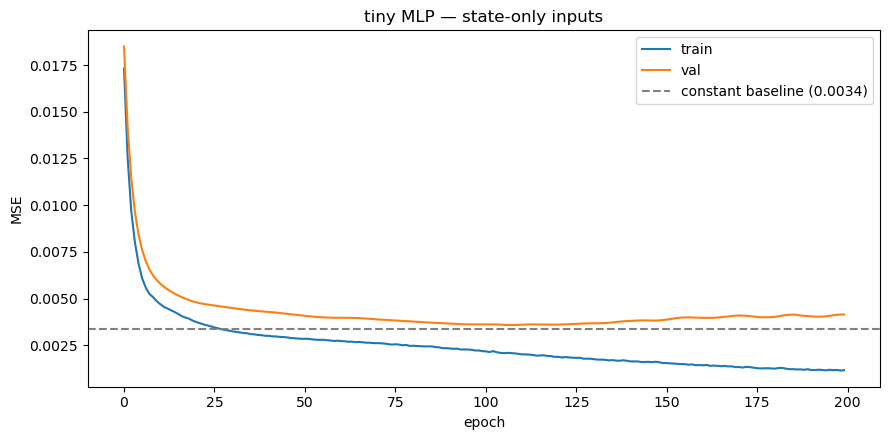

In [5]:
r4 = check4_tiny_mlp(features, log_labels, r3['val_mse'],
                     r3['train_idx'], r3['val_idx'],
                     epochs=200, hidden=128, lr=1e-3,
                     weight_decay=1e-2, target_hw=(30, 40), seed=0)
print(f"best val MSE:        {r4['best_val_mse']:.4f}")
print(f"const baseline MSE:  {r4['const_mse']:.4f}")
print(f"reduction:           {r4['reduction']:.1%}")
print(f"→ {'PASS' if r4['passed'] else 'FAIL'}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(r4['train_losses'], label="train", color="C0")
ax.plot(r4['val_losses'], label="val", color="C1")
ax.axhline(r4['const_mse'], ls="--", color="grey", label=f"constant baseline ({r4['const_mse']:.4f})")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("tiny MLP — state-only inputs")
ax.legend()
plt.tight_layout()

## Summary + decision

All four results rolled up against the plan's decision matrix.

In [6]:
import pandas as pd
rows = [
    ("Check 1: NN predictability", "≥ 2x ratio", f"{r1['ratio']:.2f}x", "PASS" if r1['passed'] else "FAIL"),
    ("Check 2: within/between var", "median < 0.5", f"{r2['median_ratio']:.3f}", "PASS" if r2['passed'] else "FAIL"),
    ("Check 3: constant baseline", "floor recorded", f"val_mse={r3['val_mse']:.4f}", "PASS (info)"),
    ("Check 4: tiny MLP",          "≥ 20% MSE reduction", f"{r4['reduction']:+.1%}", "PASS" if r4['passed'] else "FAIL"),
]
summary = pd.DataFrame(rows, columns=["check", "criterion", "result", "status"])
summary

,check,criterion,result,status
0,Check 1: NN predictability,≥ 2x ratio,3.67x,PASS
1,Check 2: within/between var,median < 0.5,0.505,FAIL
2,Check 3: constant baseline,floor recorded,val_mse=0.0038,PASS (info)
3,Check 4: tiny MLP,≥ 20% MSE reduction,-5.6%,FAIL


### Interpretation

- **Check 1 PASS strongly** → similar pre-states have meaningfully more similar labels than random pairs. The cam-projected heatmap IS predictable from the inputs we have.
- **Check 2 borderline / FAIL** → aggregation removes about half the per-failure noise, but a significant chunk survives. This means: aggregated-only training will have a lower ceiling than aggregated + failure-mode-conditioned inputs.
- **Check 3** → records the floor any trained model must beat.
- **Check 4 FAIL** → state-only inputs (7 qpos + 1 qvel norm + 64-dim depth pool) are insufficient. Image inputs (full RGB-D) are required to extract enough signal.

### Decision

Proceed with Round-3 step-4 training as planned, **with two adjustments**:

1. **Don't skip image inputs**. Check 4 says state-only is not enough; the model must consume `pre_rgb` + `pre_depth` to do anything useful.
2. **Plan a failure-mode-conditioned ablation early**. Check 2 says aggregation alone leaves real signal on the table; once the image-conditioned baseline is working, the next experiment should be per-trial training with `failure_mode` as a learned embedding fed alongside the image features.

Check 1 is the load-bearing finding: the representation IS learnable. Checks 2 and 4 just tell us what the architecture must look like and where the ceiling will be.